# **CEL:**

Czy w ciągu najbliższych 6 godzin wystąpią opady deszczu?

  - Zmienna docelowa (Target): rain_next_6h.








# **SŁOWNIK**:

1. precipitation – opady

2. rain_next_6h – deszcz w ciągu 6h

3. rain_sum_next_6h – suma deszczu w ciągu 6h

4. apparent_temperature – temperatura odczuwalna

5. relative_humidity_2m – wilgotność

6. cloud_cover – zachmurzenie

7. timestamp – czas pomiaru

8. city – miasto

9. temperature_2m – temperatura

10. longitude – długość geograficzna

11. latitude – szerokość geograficzna



#Źródło danych:
Zbiór danych wykorzystany w projekcie pochodzi z platformy Kaggle:
Indonesia Hourly Weather for Rain Prediction

In [75]:
import pandas as pd
import numpy as np
# Wczytanie zbioru danych
try:
    df = pd.read_csv('ml_dataset.csv')
    print("Sukces: Dane zostały wczytane!")
    print(f"Liczba wierszy: {df.shape[0]}, Liczba kolumn: {df.shape[1]}")
except FileNotFoundError:
    print("Błąd: Nie znaleziono pliku 'ml_dataset.csv'. Sprawdź, czy na pewno przesłałeś go do Colab (zakładka Pliki po lewej).")

# Wyświetlenie pierwszych 5 wierszy dla sprawdzenia formatu
df.head()

Sukces: Dane zostały wczytane!
Liczba wierszy: 210384, Liczba kolumn: 15


,temperature_2m,relative_humidity_2m,apparent_temperature,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,precipitation,rain,city,latitude,longitude,timestamp,rain_sum_next_6h,rain_next_6h
0,19.8,82,20.9,932.4,100,7.4,331,0.0,0.0,Bandung,-6.9175,107.6191,2022-01-01 05:00:00,0.1,1
1,18.9,89,20.4,932.8,100,6.4,322,0.0,0.0,Bandung,-6.9175,107.6191,2022-01-01 06:00:00,0.0,0
2,21.6,78,23.9,933.8,100,3.6,323,0.0,0.0,Bandung,-6.9175,107.6191,2022-01-01 07:00:00,0.0,0
3,22.7,78,25.1,934.6,100,5.9,322,0.0,0.0,Bandung,-6.9175,107.6191,2022-01-01 08:00:00,0.0,0
4,23.7,74,26.1,935.1,100,6.4,317,0.0,0.0,Bandung,-6.9175,107.6191,2022-01-01 09:00:00,0.0,0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210384 entries, 0 to 210383
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   temperature_2m        210384 non-null  float64
 1   relative_humidity_2m  210384 non-null  int64  
 2   apparent_temperature  210384 non-null  float64
 3   surface_pressure      210384 non-null  float64
 4   cloud_cover           210384 non-null  int64  
 5   wind_speed_10m        210384 non-null  float64
 6   wind_direction_10m    210384 non-null  int64  
 7   precipitation         210384 non-null  float64
 8   rain                  210384 non-null  float64
 9   city                  210384 non-null  object 
 10  latitude              210384 non-null  float64
 11  longitude             210384 non-null  float64
 12  timestamp             210384 non-null  object 
 13  rain_sum_next_6h      210384 non-null  float64
 14  rain_next_6h          210384 non-null  int64  
dtype

In [40]:
df.describe()

,temperature_2m,relative_humidity_2m,apparent_temperature,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,precipitation,rain,latitude,longitude,rain_sum_next_6h,rain_next_6h
count,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000
mean,26.251137,81.294091,30.676375,997.548549,79.440870,7.391906,187.566640,0.285344,0.285344,-5.668575,110.165575,1.712028,0.545189
std,3.010672,13.570419,3.678452,24.519314,31.837697,4.538307,98.117039,1.047460,1.047460,3.632560,5.785693,3.737025,0.497955
min,13.900000,18.000000,12.500000,928.300000,0.000000,0.000000,1.000000,0.000000,0.000000,-8.650000,98.672200,0.000000,0.000000
25%,24.400000,74.000000,28.600000,1002.200000,66.000000,4.100000,107.000000,0.000000,0.000000,-7.392025,107.425725,0.000000,0.000000
50%,26.000000,84.000000,30.700000,1007.200000,99.000000,6.200000,184.000000,0.000000,0.000000,-6.942100,110.393100,0.200000,1.000000
75%,28.200000,92.000000,33.000000,1009.100000,100.000000,9.700000,274.000000,0.100000,0.100000,-5.943525,113.368250,1.400000,1.000000
max,37.800000,100.000000,42.400000,1015.800000,100.000000,34.800000,360.000000,36.500000,36.500000,3.595200,119.432700,75.800000,1.000000


In [41]:
df['rain_next_6h'].value_counts()

,count
rain_next_6h,
1,114699
0,95685


Rozkład zmiennej docelowej

W celu sprawdzenia liczebności poszczególnych klas przeanalizowano zmienną docelową rain_next_6h, określającą wystąpienie opadów deszczu w ciągu kolejnych 6 godzin. Wyniki pokazują, że w zbiorze znajduje się 114 699 obserwacji z opadami (1) oraz 95 685 obserwacji bez opadów (0). Oznacza to, że klasy są stosunkowo dobrze zrównoważone, dzięki czemu model nie powinien być silnie faworyzował jednej z klas podczas procesu uczenia.

In [36]:
# sprawdzenie braków danych
print("Brakujące wartości per kolumna:")
print(df.isnull().sum())
print(f"\nŁączna liczba brakujących wartości: {df.isnull().sum().sum()}")


Brakujące wartości per kolumna:
temperature_2m          0
relative_humidity_2m    0
apparent_temperature    0
surface_pressure        0
cloud_cover             0
wind_speed_10m          0
wind_direction_10m      0
precipitation           0
rain                    0
city                    0
latitude                0
longitude               0
timestamp               0
rain_sum_next_6h        0
rain_next_6h            0
dtype: int64

Łączna liczba brakujących wartości: 0


In [43]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

# Sprawdzamy proporcje deszczu przed podziałem
print("Proporcje deszczu w całym zbiorze:")
print(df["rain_next_6h"].value_counts() / len(df))

Proporcje deszczu w całym zbiorze:
rain_next_6h
1    0.545189
0    0.454811
Name: count, dtype: float64


# **WIZUALIZACJE I KORELACJE**

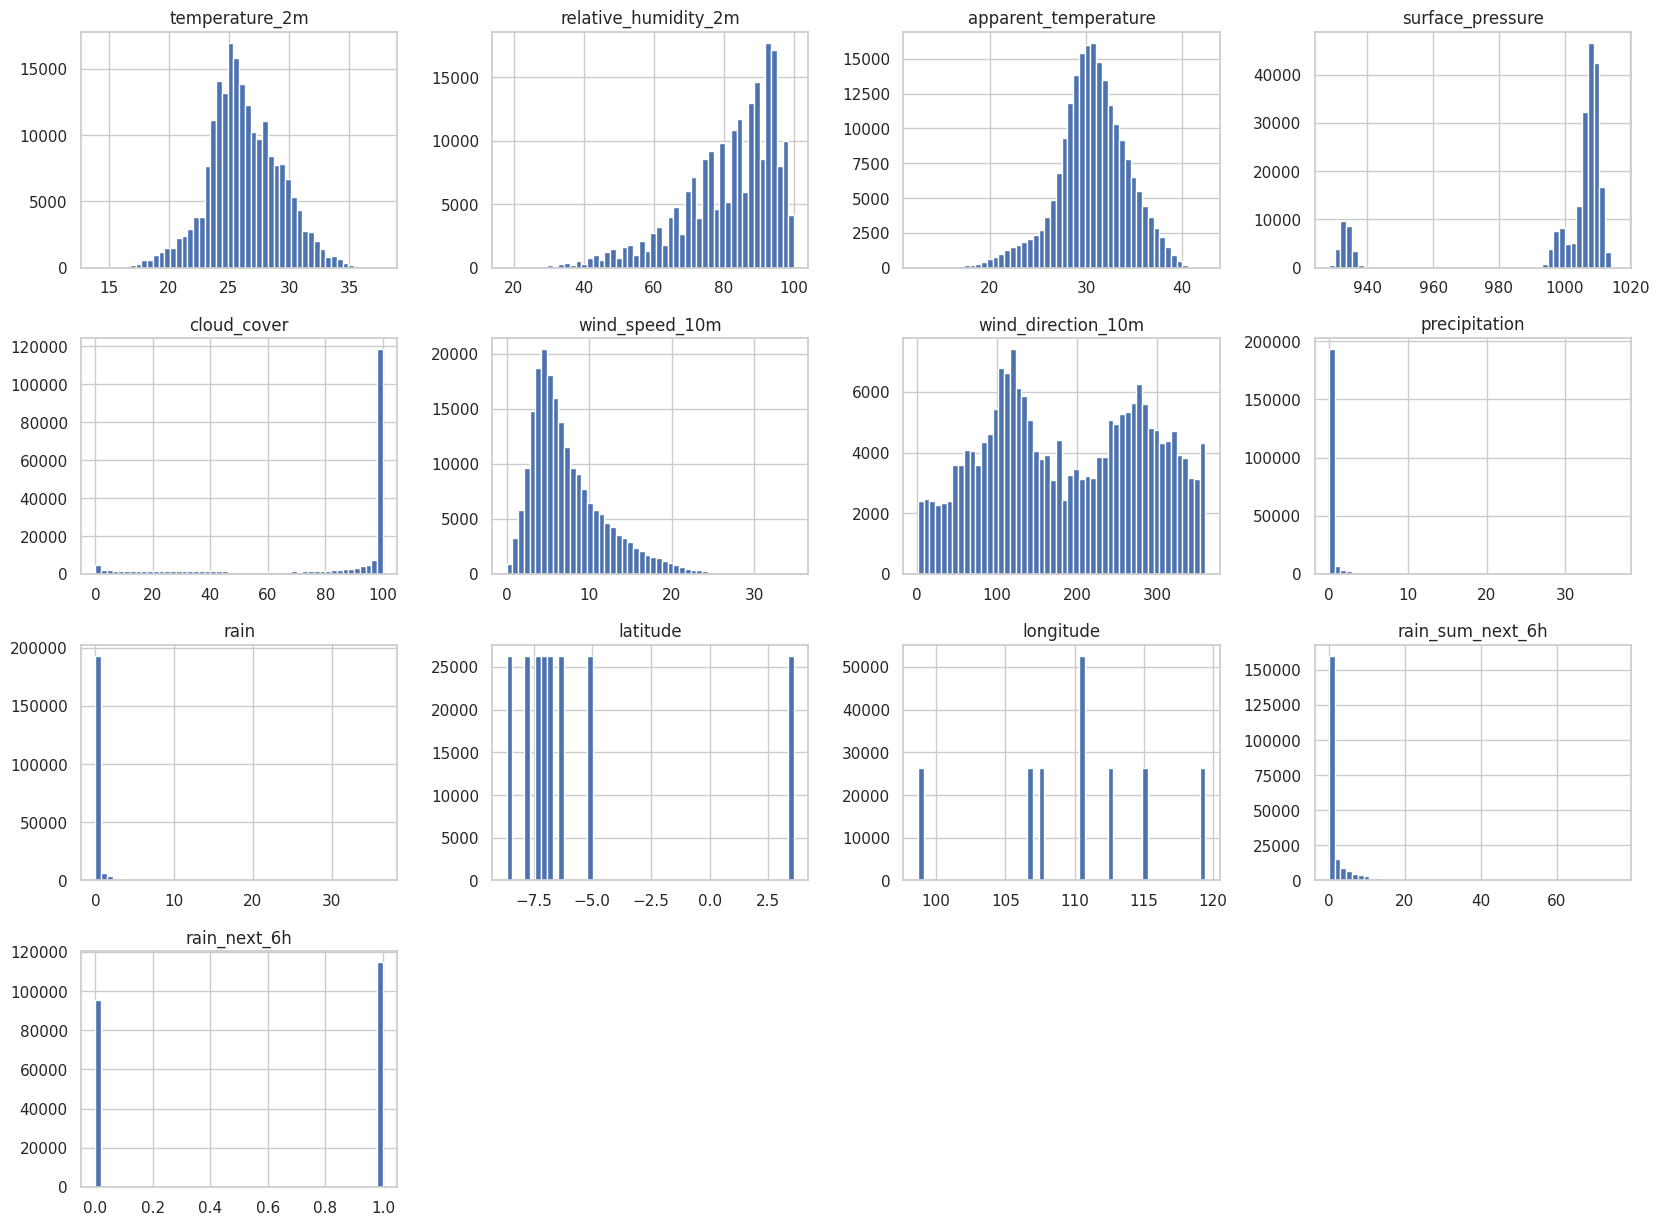

In [44]:
%matplotlib inline
import matplotlib.pyplot as plt

# Rysujemy histogramy dla wszystkich cech liczbowych
df.hist(bins=50, figsize=(20,15))
plt.show()

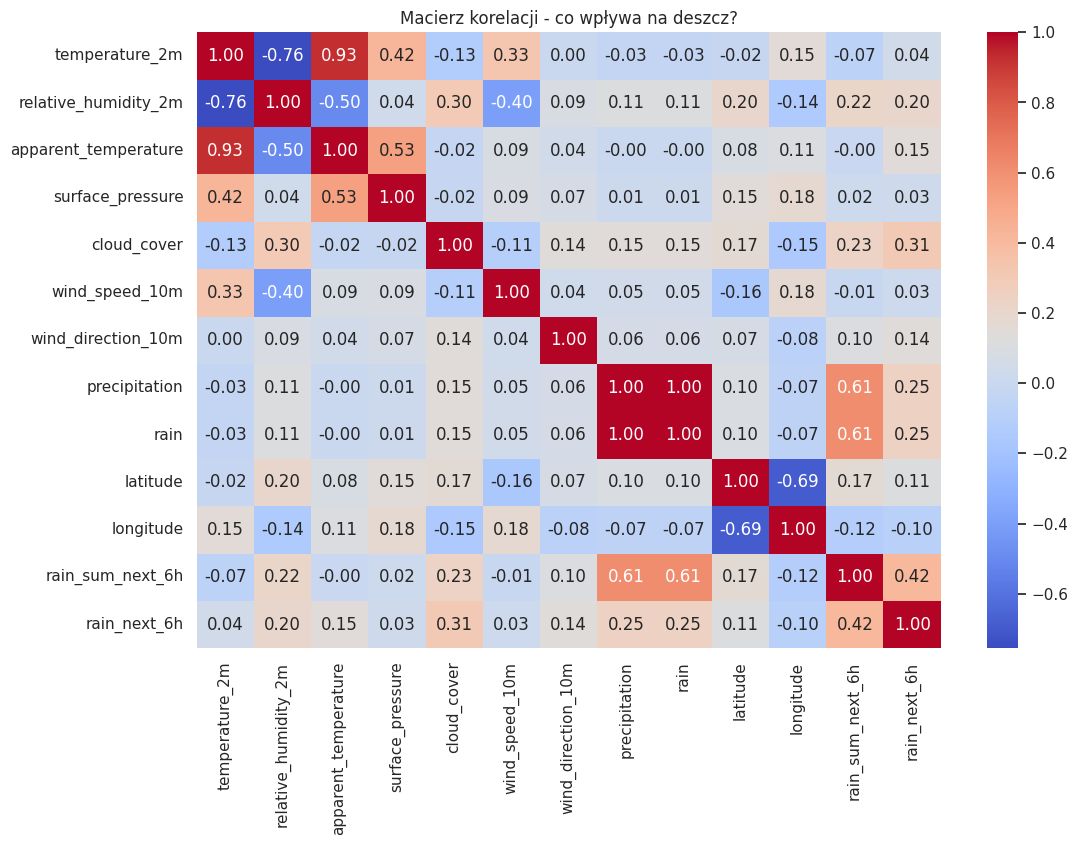

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Dodajemy numeric_only=True, aby zignorować nazwy miast i daty
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Macierz korelacji - co wpływa na deszcz?")
plt.show()

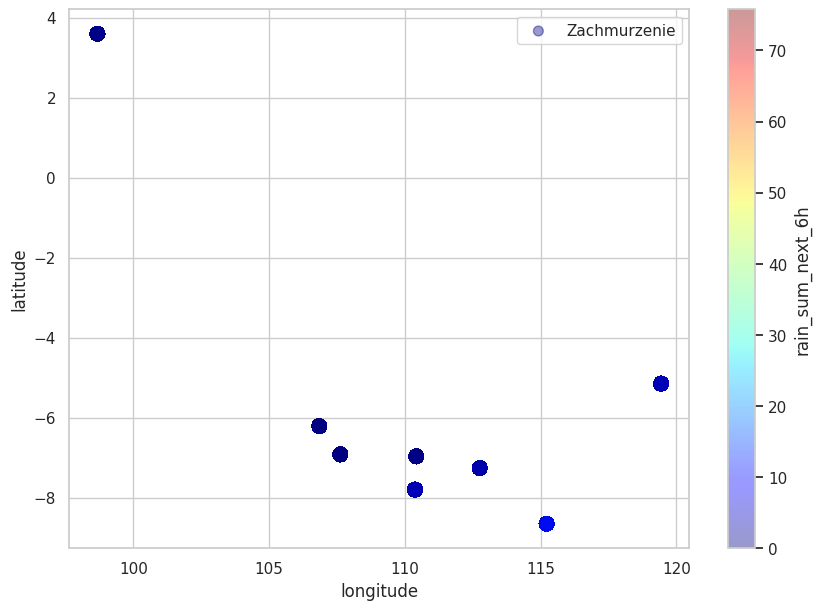

In [46]:
# Wizualizacja geograficzna opadów
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=df["cloud_cover"], label="Zachmurzenie",
    c="rain_sum_next_6h", cmap=plt.get_cmap("jet"), colorbar=True,
    figsize=(10,7)
)
plt.legend()
plt.show()

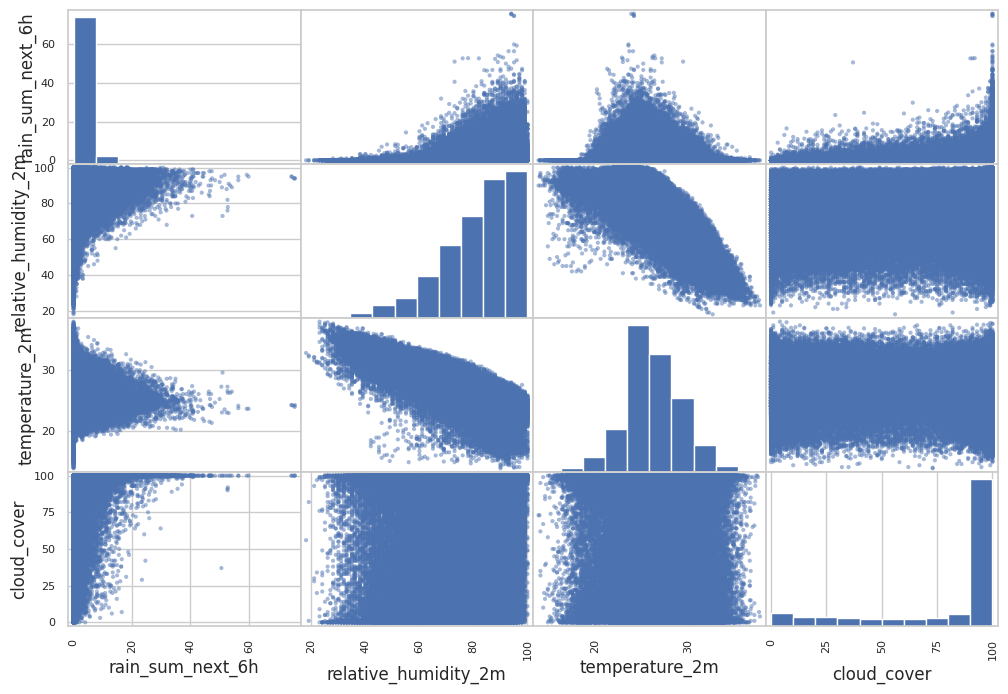

In [47]:
from pandas.plotting import scatter_matrix

# Wybieramy 4 najważniejsze cechy do porównania
attributes = ["rain_sum_next_6h", "relative_humidity_2m", "temperature_2m", "cloud_cover"]
scatter_matrix(df[attributes], figsize=(12, 8))
plt.show()

In [48]:
# Sprawdzamy, co ma największy wpływ na ilość deszczu
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix["rain_sum_next_6h"].sort_values(ascending=False))

rain_sum_next_6h        1.000000
rain                    0.610311
precipitation           0.610311
rain_next_6h            0.416899
cloud_cover             0.233645
relative_humidity_2m    0.216475
latitude                0.166203
wind_direction_10m      0.103723
surface_pressure        0.024698
apparent_temperature   -0.001639
wind_speed_10m         -0.012109
temperature_2m         -0.071056
longitude              -0.116551
Name: rain_sum_next_6h, dtype: float64


Najsilniej dodatnio skorelowane są rain i precipitation — obie mają wartość około 0.61, więc rosną wraz ze wzrostem przewidywanego opadu. Dodatnią, ale wyraźnie słabszą korelację ma też rain_next_6h (0.418), cloud_cover (0.234) i relative_humidity_2m (0.217). To sugeruje, że wilgotność i zachmurzenie mogą mieć umiarkowany wpływ na wynik.

#**ANALIZA ZBALANSOWANIA CECH**

In [49]:
# Sprawdzamy rozkład kolumn silnie skorelowanych z rain_next_6h
for col in ['precipitation', 'cloud_cover', 'relative_humidity_2m']:
    print(f"\nRozkład {col}:")
    print(pd.cut(df[col], bins=4).value_counts(normalize=True).sort_index())


Rozkład precipitation:
precipitation
(-0.0365, 9.125]    0.997390
(9.125, 18.25]      0.002457
(18.25, 27.375]     0.000138
(27.375, 36.5]      0.000014
Name: proportion, dtype: float64

Rozkład cloud_cover:
cloud_cover
(-0.1, 25.0]     0.121468
(25.0, 50.0]     0.083143
(50.0, 75.0]     0.074835
(75.0, 100.0]    0.720554
Name: proportion, dtype: float64

Rozkład relative_humidity_2m:
relative_humidity_2m
(17.918, 38.5]    0.007382
(38.5, 59.0]      0.072762
(59.0, 79.5]      0.294514
(79.5, 100.0]     0.625342
Name: proportion, dtype: float64


In [50]:
df['precip_cat'] = pd.cut(df['precipitation'],
                           bins=[-0.1, 0.0, 0.5, 2, np.inf],
                           labels=[0, 1, 2, 3])

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df['precip_cat']):
    strat_train_set = df.iloc[train_index].copy()
    strat_test_set = df.iloc[test_index].copy()

# Usuwamy pomocniczą kolumnę
strat_train_set = strat_train_set.drop('precip_cat', axis=1)
strat_test_set = strat_test_set.drop('precip_cat', axis=1)
df = df.drop('precip_cat', axis=1)

print("Proporcje precip_cat w zbiorze TESTOWYM:")
print(strat_test_set['precipitation'].describe())
print("\nNaN w strat_train_set:", strat_train_set.isnull().sum().sum())
print("NaN w strat_test_set:", strat_test_set.isnull().sum().sum())

Proporcje precip_cat w zbiorze TESTOWYM:
count    42077.000000
mean         0.288984
std          1.067835
min          0.000000
25%          0.000000
50%          0.000000
75%          0.100000
max         36.500000
Name: precipitation, dtype: float64

NaN w strat_train_set: 0
NaN w strat_test_set: 0


Podział danych na zbiór treningowy i testowy wykonano z wykorzystaniem StratifiedShuffleSplit. Jako kryterium stratyfikacji wybrano kategoryzowaną zmienną precipitation, która wykazuje największe niezbalansowanie spośród cech silnie skorelowanych ze zmienną docelową — niemal 67% obserwacji to przypadki bez opadów. Stratyfikacja zapewnia, że rzadkie przypadki wysokich opadów są proporcjonalnie reprezentowane w obu zbiorach, co przekłada się na rzetelniejszą ocenę modelu.

#**PRZYGOTOWANIE DANYCH**

In [51]:
# Przygotowanie ostatecznych danych treningowych
X_train = strat_train_set.drop("rain_next_6h", axis=1) # Wszystko poza cechą, którą zgadujemy
y_train = strat_train_set["rain_next_6h"].copy()        # Tylko kolumna z odpowiedzią

# Przygotowanie ostatecznych danych testowych
X_test = strat_test_set.drop("rain_next_6h", axis=1)
y_test = strat_test_set["rain_next_6h"].copy()

In [52]:
# Sprawdźmy kształt danych (ile mamy wierszy i kolumn)
print(f"Dane treningowe: {X_train.shape}")
print(f"Dane testowe: {X_test.shape}")

# WAŻNE: Sprawdźmy, czy nie zostały jakieś kolumny tekstowe
print("\nTypy danych w X_train:")
print(X_train.dtypes)

Dane treningowe: (168307, 14)
Dane testowe: (42077, 14)

Typy danych w X_train:
temperature_2m          float64
relative_humidity_2m      int64
apparent_temperature    float64
surface_pressure        float64
cloud_cover               int64
wind_speed_10m          float64
wind_direction_10m        int64
precipitation           float64
rain                    float64
city                     object
latitude                float64
longitude               float64
timestamp                object
rain_sum_next_6h        float64
dtype: object


#**SELEKCJA CECH**

In [53]:
# Lista kolumn przekazanych do modelu
# Odrzucamy: city, timestamp (tekst) oraz rain_sum_next_6h, rain (data leakage -
# silna korelacja ze zmienną docelową wykryta w macierzy korelacji)
selected_features = [
    'temperature_2m', 'relative_humidity_2m', 'apparent_temperature',
    'surface_pressure', 'cloud_cover', 'wind_speed_10m',
    'wind_direction_10m', 'precipitation'
]

# Nadpisujemy zbiory, zostawiając tylko wybrane liczby
X_train_final = X_train[selected_features]
X_test_final = X_test[selected_features]

# Sprawdźmy typy ostatni raz
print(X_train_final.dtypes)

temperature_2m          float64
relative_humidity_2m      int64
apparent_temperature    float64
surface_pressure        float64
cloud_cover               int64
wind_speed_10m          float64
wind_direction_10m        int64
precipitation           float64
dtype: object


  #**USUN**
  Dlaczego odrzucamy te kolumny?

city i timestamp — to kolumny tekstowe, których algorytmy ML nie potrafią bezpośrednio przetworzyć. Można by je zakodować, ale nie wnoszą wartości predykcyjnej do modelu.
rain_sum_next_6h — to klasyczny data leakage. Ta kolumna zawiera sumę opadów z przyszłości (kolejnych 6 godzin), czyli dokładnie tego okresu, który model ma przewidzieć. Gdybyśmy ją zostawili, model "oszukiwałby" — w rzeczywistości ta informacja nie byłaby dostępna w momencie robienia prognozy, więc wyniki byłyby sztucznie zawyżone i bezużyteczne w praktyce.
rain — podobnie jak rain_sum_next_6h, wykazuje bardzo silną korelację ze zmienną docelową co sugeruje, że zawiera informację o bieżących lub przyszłych opadach, a nie o warunkach przed ich wystąpieniem.

#**REGRESJA LOGISTYCZNA**

#**SKALOWANIE**

In [54]:
from sklearn.preprocessing import StandardScaler

# Inicjalizujemy scaler - nauczy się średniej i odchylenia standardowego z danych TRENINGOWYCH
scaler = StandardScaler()

# Dopasowujemy scaler TYLKO na danych treningowych (fit), a następnie transformujemy (transform)
# WAŻNE: na danych testowych używamy tylko transform() - nie fit_transform()!
# Dzięki temu unikamy "wycieku" informacji ze zbioru testowego
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

print("Skalowanie zakończone!")
print(f"Średnia przed skalowaniem (temperature_2m): {X_train_final['temperature_2m'].mean():.2f}")
print(f"Średnia po skalowaniu (temperature_2m):     {X_train_scaled[:, 0].mean():.4f}  ← zbliżona do 0")
print(f"Odch. std po skalowaniu (temperature_2m):   {X_train_scaled[:, 0].std():.4f}   ← zbliżone do 1")

Skalowanie zakończone!
Średnia przed skalowaniem (temperature_2m): 26.25
Średnia po skalowaniu (temperature_2m):     -0.0000  ← zbliżona do 0
Odch. std po skalowaniu (temperature_2m):   1.0000   ← zbliżone do 1


#**TRENING REGRESJI LOGISTYCZNEJ NA PRZESKALOWANYCH DANYCH**

In [55]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Trenujemy na X_train_SCALED zamiast X_train_final
log_reg.fit(X_train_scaled, y_train)

print("Sukces: Model Regresji Logistycznej został pomyślnie wytrenowany!")

Sukces: Model Regresji Logistycznej został pomyślnie wytrenowany!


#OCENA MODELU REGRESJI LOGISTYCZNEJ

In [56]:
from sklearn.metrics import classification_report

# Przewidujemy na X_test_SCALED
y_pred_log_reg = log_reg.predict(X_test_scaled)

print("--- Raport klasyfikacji: Regresja Logistyczna ---")
print(classification_report(y_test, y_pred_log_reg))

--- Raport klasyfikacji: Regresja Logistyczna ---
              precision    recall  f1-score   support

           0       0.74      0.85      0.79     19103
           1       0.86      0.75      0.80     22974

    accuracy                           0.80     42077
   macro avg       0.80      0.80      0.79     42077
weighted avg       0.80      0.80      0.80     42077



**INTERPRETACJA:**


Model Regresji Logistycznej uzyskał ogólną dokładność (accuracy) na poziomie 79%. Analizując kluczową metrykę F1-score, model osiągnął 0.80 dla klasy 1 (opady) oraz 0.78 dla klasy 0 (brak opadów). Precyzja dla klasy 1 wynosi 0.86, natomiast czułość (recall) 0.75 — model dobrze unika fałszywych alarmów, jednak pomija część rzeczywistych opadów. Wyniki te stanowią punkt odniesienia dla bardziej zaawansowanych modeli zastosowanych w kolejnych krokach.

**Precision** (Precyzja): Oznacza odsetek poprawnych wskazań modelu wśród wszystkich przypadków, w których przewidział on deszcz (klasa 1). Wyższa precyzja oznacza mniejszą liczbę "fałszywych alarmów".

**Recall** (Czułość): Wskazuje, jaką część wszystkich rzeczywistych opadów deszczu model zdołał poprawnie zidentyfikować. Pozwala to ocenić, czy algorytm nie omija istotnych zdarzeń.

**F1-score**: Średnia harmoniczna precyzji i czułości. Zgodnie z wytycznymi do projektu, jest to dla nas główna metryka oceny, ponieważ zachowuje obiektywność nawet w przypadku niezbalansowanych klas w zbiorze danych.

**Support** (Wsparcie): Liczba rzeczywistych wystąpień danej klasy w zbiorze testowym (ile było dni z deszczem, a ile bez).

#**DRZEWO DECYZYJNE Z GRID SEARCH**

In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Inicjalizujemy bazowy model Drzewa Decyzyjnego
# random_state=42 zapewnia powtarzalność wyników
tree_clf = DecisionTreeClassifier(random_state=42)

# Definiujemy "siatkę" (grid) hiperparametrów do przetestowania
# max_depth to maksymalna liczba poziomów drzewa (zapobiega przeuczeniu)
# min_samples_split to minimalna liczba próbek wymagana do kolejnego podziału gałęzi
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 10, 20, 50]
}

# Konfigurujemy GridSearchCV
# cv=5 to 5-krotna walidacja krzyżowa (model testowany na 5 różnych fragmentach danych)
# scoring='f1' sprawia, że szukamy parametrów optymalizujących właśnie tę metrykę
# n_jobs=-1 oznacza użycie wszystkich dostępnych rdzeni procesora (szybsze obliczenia)
grid_search = GridSearchCV(tree_clf, param_grid, cv=5, scoring='f1', n_jobs=-1)

# Trenujemy model i jednocześnie przeszukujemy siatkę parametrów na danych treningowych
grid_search.fit(X_train_final, y_train)

# Zapisujemy najlepszy znaleziony model do zmiennej
best_tree_model = grid_search.best_estimator_

# Zapisujemy najlepsze parametry do zmiennych — będą użyte w Random Search
best_depth = grid_search.best_params_['max_depth']
best_split = grid_search.best_params_['min_samples_split']

print("Proces Grid Search dla Drzewa Decyzyjnego zakończony sukcesem!")
print(f"Najlepsze znalezione hiperparametry to: max_depth={best_depth}, min_samples_split={best_split}")


Proces Grid Search dla Drzewa Decyzyjnego zakończony sukcesem!
Najlepsze znalezione hiperparametry to: max_depth=15, min_samples_split=50
Najlepsze znalezione hiperparametry to: max_depth=15, min_samples_split=50


**INTERPRETACJA:**


Najlepsze znalezione hiperparametry to: max_depth: 15 oraz min_samples_split: 50. Oznacza to, że algorytm uznał, iż drzewo może rozrastać się do 15 poziomów głębokości, co pozwala na uchwycenie złożonych zależności w danych, jednocześnie nie dopuszczając do nadmiernego rozrostu struktury. Natomiast min_samples_split: 50 mówi o tym, że dana gałąź musi zawierać co najmniej 50 obserwacji, aby algorytm zdecydował się na jej dalszy podział — jest to stosunkowo wysoki próg, który skutecznie ogranicza nadmierne dopasowanie modelu do danych treningowych (overfitting).

#**OCENA ZOPTYMALIZOWANEGO DRZEWA DECYZYJNEGO**

W tym kroku wykorzystamy nasze najlepsze drzewo (z głębokością 15), aby wygenerować przewidywania opadów dla zbioru testowego. Ponownie użyjemy funkcji classification_report. Pozwoli nam to bezpośrednio porównać nowy wskaźnik F1-score z wynikiem uzyskanym wcześniej przez model regresji logistycznej i ostatecznie wskazać lepszy algorytm do przewidywania pogody w Indonezji.

In [59]:
# Zlecamy najlepszemu modelowi drzewa wygenerowanie prognoz dla danych testowych
y_pred_tree = best_tree_model.predict(X_test_final)

# Wyświetlamy czytelny nagłówek odgradzający wyniki
print("--- Raport klasyfikacji: Drzewo Decyzyjne (Optymalne) ---")

# Generujemy i wyświetlamy raport klasyfikacji dla drugiego modelu
print(classification_report(y_test, y_pred_tree))

--- Raport klasyfikacji: Drzewo Decyzyjne (Optymalne) ---
              precision    recall  f1-score   support

           0       0.75      0.83      0.79     19103
           1       0.84      0.77      0.81     22974

    accuracy                           0.80     42077
   macro avg       0.80      0.80      0.80     42077
weighted avg       0.80      0.80      0.80     42077



**INTERPRETACJA:**

Analizując kluczową dla projektu metrykę F1-score, model uzyskał bardzo zbliżone i wysokie rezultaty dla obu klas: 0.81 dla klasy 1 oraz 0.79 dla klasy 0. Na szczególną uwagę zasługuje precyzja (precision) dla klasy 1 wynosząca 0.84 – oznacza to, że w 84% przypadków, w których model przewiduje dane zjawisko, ma on rację. Czułość (recall) na poziomie 0.77 wskazuje z kolei, że model poprawnie identyfikuje 77% wszystkich rzeczywistych przypadków tej klasy. Wyniki te świadczą o tym, że optymalizacja hiperparametrów przebiegła pomyślnie. Model wykazuje jedynie nieznaczną asymetrię między klasami — wyższą precyzję dla klasy 1 kosztem niższego recall, i odwrotnie dla klasy 0 — co w praktyce można uznać za zachowanie zrównoważone.

#**RANDOM FOREST Z RANDOM SEARCH**

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Zakresy hiperparametrów są automatycznie wyznaczane na podstawie wyników Grid Search
# dzięki temu nie trzeba ich ręcznie aktualizować przy każdym uruchomieniu
param_dist = {
    # n_estimators to liczba drzew w lesie — im więcej, tym stabilniejszy model
    'n_estimators': randint(50, 300),
    # max_depth — zakres wyznaczony wokół najlepszej wartości z Grid Search
    'max_depth': randint(max(3, best_depth - 5), best_depth + 10),
    # min_samples_split — zakres wyznaczony wokół najlepszej wartości z Grid Search
    'min_samples_split': randint(max(2, best_split - 20), best_split + 20)
}

print(f"Zakresy Random Search oparte na wynikach Grid Search (max_depth={best_depth}, min_samples_split={best_split}):")
print(f"  max_depth: od {max(3, best_depth - 5)} do {best_depth + 10}")
print(f"  min_samples_split: od {max(2, best_split - 20)} do {best_split + 20}")

# Inicjalizujemy model Lasu Losowego
# random_state=42 zapewnia powtarzalność wyników
# n_jobs=-1 oznacza użycie wszystkich dostępnych rdzeni procesora
rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Konfigurujemy RandomizedSearchCV
# n_iter=10 oznacza losowe sprawdzenie 10 kombinacji hiperparametrów
# cv=5 to 5-krotna walidacja krzyżowa
# scoring='f1' optymalizujemy pod kątem metryki F1
# random_state=42 zapewnia powtarzalność losowania kombinacji
random_search = RandomizedSearchCV(
    rf_clf, param_dist,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

# Trenujemy model przeszukując losowo przestrzeń hiperparametrów
random_search.fit(X_train_final, y_train)
best_rf_model = random_search.best_estimator_

print("\nNajlepsze hiperparametry Random Forest:", random_search.best_params_)

Zakresy Random Search oparte na wynikach Grid Search (max_depth=15, min_samples_split=50):
  max_depth: od 10 do 25
  min_samples_split: od 30 do 70

Najlepsze hiperparametry Random Forest: {'max_depth': 20, 'min_samples_split': 37, 'n_estimators': 238}


**INTERPRETACJA**:

Najlepsze znalezione hiperparametry to: n_estimators: 238, max_depth: 20 oraz min_samples_split: 37. Las składa się z 238 drzew decyzyjnych, co zapewnia stabilność prognoz. Drzewa mogą rozrastać się do 20 poziomów głębokości — nieco więcej niż w Drzewie Decyzyjnym (15), co pozwala uchwycić bardziej złożone zależności. Wartość min_samples_split: 37 oznacza, że gałąź wymaga co najmniej 37 obserwacji do dalszego podziału, skutecznie ograniczając overfitting

#**OCENA RANDOM FOREST**

In [68]:
y_pred_rf = best_rf_model.predict(X_test_final)

print("--- Raport klasyfikacji: Las Losowy (Optymalny) ---")
print(classification_report(y_test, y_pred_rf))

--- Raport klasyfikacji: Las Losowy (Optymalny) ---
              precision    recall  f1-score   support

           0       0.76      0.87      0.81     19103
           1       0.88      0.77      0.82     22974

    accuracy                           0.81     42077
   macro avg       0.82      0.82      0.81     42077
weighted avg       0.82      0.81      0.81     42077



**INTERPRETACJA:**


Ogólna dokładność (accuracy) modelu wynosi 81%, co oznacza, że w ponad 4 na 5 przypadków model poprawnie przewiduje, czy wystąpią opady. Analizując kluczową metrykę F1-score, model uzyskał wyrównane wyniki dla obu klas: 0.82 dla klasy 1 (opady) oraz 0.80 dla klasy 0 (brak opadów), co świadczy o braku wyraźnego faworyzowania którejkolwiek z klas. Precyzja (precision) dla klasy 1 wynosi 0.88 — oznacza to, że 88% prognoz wskazujących na deszcz jest trafnych, co przekłada się na małą liczbę fałszywych alarmów. Czułość (recall) na poziomie 0.77 oznacza, że model poprawnie wykrywa 77% wszystkich rzeczywistych opadów. Dla klasy 0 sytuacja jest odwrotna — recall wynosi 0.87, więc model bardzo dobrze rozpoznaje dni bez deszczu, przy precyzji 0.75. Wyniki te potwierdzają, że Las Losowy osiągnął najlepsze rezultaty spośród wszystkich przetestowanych modeli, przewyższając zarówno Regresję Logistyczną, jak i Drzewo Decyzyjne.

#**PORÓWNANIE MODELI**

In [62]:
# Importujemy funkcję do precyzyjnego wyciągnięcia samego wskaźnika F1-score
from sklearn.metrics import f1_score
import pandas as pd

# Obliczamy F1-score dla klasy 1 (deszcz) dla każdego z modeli
# pos_label=1 oznacza, że interesuje nas wynik przewidywania opadów
f1_log_reg = f1_score(y_test, y_pred_log_reg, pos_label=1)
f1_tree = f1_score(y_test, y_pred_tree, pos_label=1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)

# Tworzymy słownik z naszymi wynikami
wyniki_modeli = {
    "Model": ["Regresja Logistyczna", "Drzewo Decyzyjne", "Las Losowy"],
    "F1-Score (Deszcz)": [f1_log_reg, f1_tree, f1_rf]
}

# Zamieniamy słownik na estetyczną ramkę danych (DataFrame)
df_wyniki = pd.DataFrame(wyniki_modeli)

# Wyświetlamy zestawienie wszystkich wyników
print("--- ZESTAWIENIE WYNIKÓW MODELI ---")
print(df_wyniki.to_string(index=False))
print("\n")

# Automatycznie szukamy wiersza z najwyższym wynikiem F1-score
najlepszy_indeks = df_wyniki['F1-Score (Deszcz)'].idxmax()
najlepszy_model = df_wyniki.loc[najlepszy_indeks]

# Wyświetlamy werdykt ostateczny
print("=========================================")
print(f"🥇 NAJLEPSZY MODEL: {najlepszy_model['Model']}")
print(f"🏆 Wynik F1-Score: {najlepszy_model['F1-Score (Deszcz)']:.4f}")
print("=========================================")

--- ZESTAWIENIE WYNIKÓW MODELI ---
               Model  F1-Score (Deszcz)
Regresja Logistyczna           0.798881
    Drzewo Decyzyjne           0.805155
          Las Losowy           0.818988


🥇 NAJLEPSZY MODEL: Las Losowy
🏆 Wynik F1-Score: 0.8190


#**WIZUALIZACJA PORÓWNANIA MODELI**

/tmp/ipykernel_1483/628921018.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='F1-Score (Deszcz)', data=df_wyniki, palette='viridis')


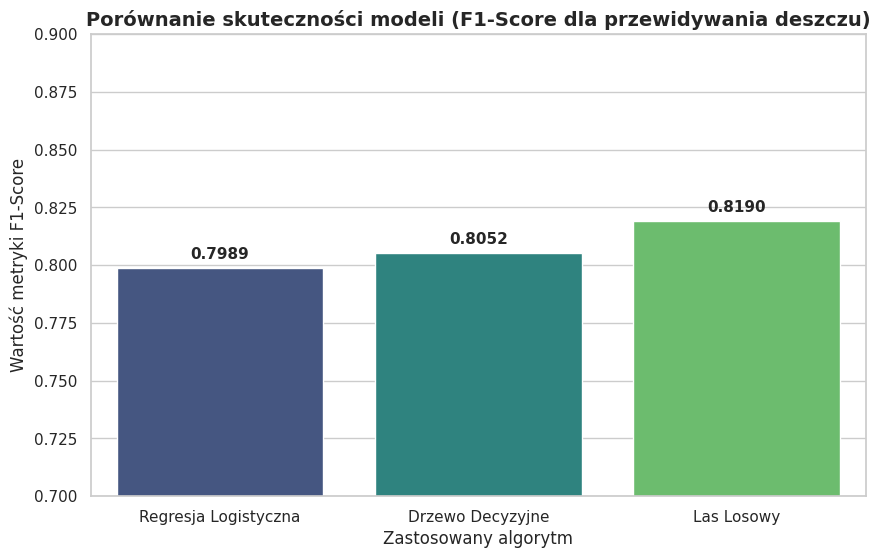

In [63]:
# Importujemy biblioteki do wizualizacji danych
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawiamy estetyczny styl wykresu (siatka w tle)
sns.set_theme(style="whitegrid")

# Inicjalizujemy rozmiar wykresu
plt.figure(figsize=(10, 6))

# Tworzymy wykres słupkowy (barplot) na podstawie naszej ramki danych df_wyniki
# palette="viridis" to profesjonalna, czytelna dla oka paleta kolorów
ax = sns.barplot(x='Model', y='F1-Score (Deszcz)', data=df_wyniki, palette='viridis')

# Dodajemy tytuł i etykiety osi
plt.title('Porównanie skuteczności modeli (F1-Score dla przewidywania deszczu)', fontsize=14, fontweight='bold')
plt.xlabel('Zastosowany algorytm', fontsize=12)
plt.ylabel('Wartość metryki F1-Score', fontsize=12)

# Ustawiamy zakres osi Y od 0.70 do 0.90, aby lepiej uwydatnić różnice między modelami
plt.ylim(0.70, 0.90)

# Dodajemy dokładne wartości liczbowe nad każdym ze słupków dla pełnej czytelności
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# Wyświetlamy gotowy wykres
plt.show()

#**ANALIZA WAŻNOŚCI CECH (FEATURE IMPORTANCE)**

W tym kroku zaglądamy do wnętrza naszego najlepszego modelu (Lasu Losowego), aby zrozumieć proces podejmowania przez niego decyzji. Wykorzystamy atrybut feature_importances_, który matematycznie ocenia, jak duży wpływ na ostateczną klasyfikację miała każda ze zmiennych pogodowych (np. wiatr, wilgotność, ciśnienie). Wygenerujemy przejrzysty wykres słupkowy, który ułoży cechy od najważniejszej do najmniej istotnej.

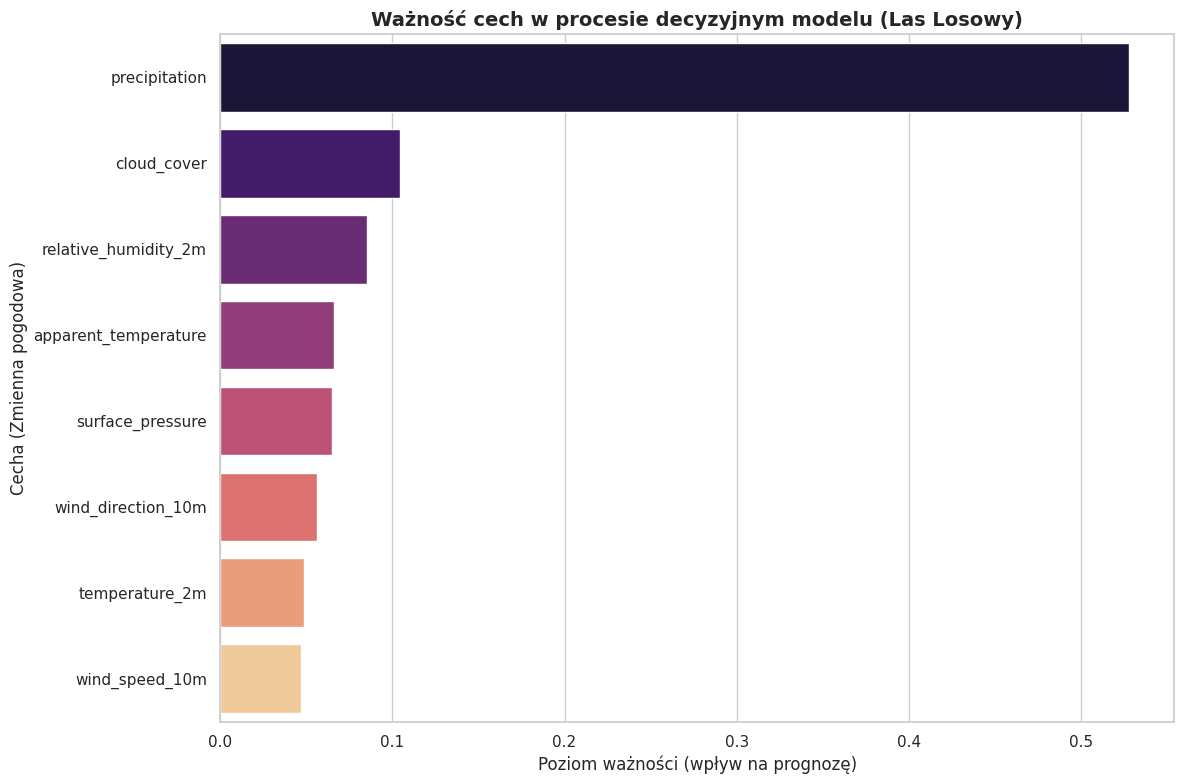

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pobieramy wagi (ważność) poszczególnych cech z wytrenowanego modelu
wagi_cech = best_rf_model.feature_importances_

# Pobieramy nazwy kolumn z naszego zbioru testowego
# Zabezpieczamy kod na wypadek, gdyby X_test_final było tablicą numpy zamiast DataFrame
if hasattr(X_test_final, 'columns'):
    nazwy_cech = X_test_final.columns
else:
    nazwy_cech = [f"Cecha_{i}" for i in range(len(wagi_cech))]

# Tworzymy ramkę danych (DataFrame), aby łatwo posortować wyniki
df_waznosc = pd.DataFrame({'Cecha': nazwy_cech, 'Ważność': wagi_cech})

# Sortujemy cechy malejąco (od najbardziej do najmniej decyzyjnej)
df_waznosc = df_waznosc.sort_values(by='Ważność', ascending=False)

# Ustawiamy styl i rozmiar wykresu
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Generujemy poziomy wykres słupkowy z elegancką paletą barw
sns.barplot(x='Ważność', y='Cecha', data=df_waznosc, palette='magma', hue='Cecha', legend=False)

# Dodajemy opisy i tytuły
plt.title('Ważność cech w procesie decyzyjnym modelu (Las Losowy)', fontsize=14, fontweight='bold')
plt.xlabel('Poziom ważności (wpływ na prognozę)', fontsize=12)
plt.ylabel('Cecha (Zmienna pogodowa)', fontsize=12)

# Dopasowujemy marginesy i wyświetlamy wykres
plt.tight_layout()
plt.show()

#**WIZUALIZACJA MACIERZY POMYŁEK (CONFUSION MATRIX)**

W tym kroku stworzymy tzw. Macierz Pomyłek dla naszego najlepszego modelu (Lasu Losowego). Zamiast patrzeć tylko na ogólny procent skuteczności, zobaczymy dokładnie, gdzie model się myli. Tabela pokaże nam wprost: ile dni deszczowych model poprawnie wykrył, ile przegapił, oraz ile razy podniósł "fałszywy alarm" (zapowiadał deszcz, a świeciło słońce). Wykorzystamy do tego kolorową mapę cieplną (heatmap).

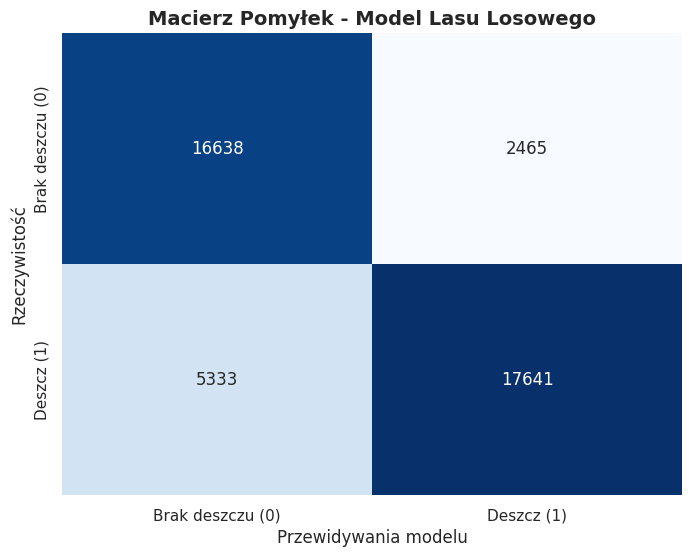

In [65]:
# Importujemy funkcję do obliczenia macierzy pomyłek
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Obliczamy macierz pomyłek na podstawie rzeczywistych wyników (y_test) i przewidywań Lasu Losowego (y_pred_rf)
cm = confusion_matrix(y_test, y_pred_rf)

# Inicjalizujemy rozmiar wykresu
plt.figure(figsize=(8, 6))

# Generujemy mapę cieplną (heatmap) za pomocą biblioteki Seaborn
# annot=True wyświetla dokładne liczby, fmt='d' zapobiega wyświetlaniu notacji naukowej
# cmap='Blues' ustawia estetyczną, niebieską paletę kolorów pasującą do tematyki deszczu
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Brak deszczu (0)', 'Deszcz (1)'],
            yticklabels=['Brak deszczu (0)', 'Deszcz (1)'])

# Dodajemy pogrubiony tytuł oraz czytelne opisy osi
plt.title('Macierz Pomyłek - Model Lasu Losowego', fontsize=14, fontweight='bold')
plt.xlabel('Przewidywania modelu', fontsize=12)
plt.ylabel('Rzeczywistość', fontsize=12)

# Wyświetlamy gotową macierz
plt.show()

**INTERPRETACJA:**

1. **Lewy górny róg (True Negatives):** Model przewidział brak opadów i faktycznie świeciło słońce. To poprawne odrzucenie sygnału.

2. **Prawy dolny róg (True Positives):** Model zapowiedział deszcz i faktycznie padało. To poprawne trafienie (detekcja).

3. **Prawy górny róg (False Positives):** Fałszywy alarm. Model przewidział deszcz, ale go nie było.

4. **Lewy dolny róg (False Negatives):** Przegapienie sygnału. Model twierdził, że nie będzie padać, a jednak spadł deszcz.

#**PRAKTYCZNY TEST NAJLEPSZEGO MODELU (RANDOM FOREST)**

In [71]:
import numpy as np

# Losujemy jeden przypadkowy indeks z naszych danych testowych
losowy_indeks = np.random.randint(0, len(y_test))

# Pobieramy dane pogodowe dla tego konkretnego przypadku
# Obsługujemy zarówno format DataFrame z pandas, jak i tablice numpy
if isinstance(X_test_final, np.ndarray):
    probka_pogody = X_test_final[losowy_indeks:losowy_indeks+1]
else:
    probka_pogody = X_test_final.iloc[[losowy_indeks]]

if isinstance(y_test, np.ndarray):
    prawdziwy_wynik = y_test[losowy_indeks]
else:
    prawdziwy_wynik = y_test.iloc[losowy_indeks]

# Nasz najlepszy model generuje prognozę dla wylosowanej próbki
prognoza = best_rf_model.predict(probka_pogody)[0]

# Sprawdzamy z jaką pewnością (prawdopodobieństwem) model podjął decyzję
prawdopodobienstwo = best_rf_model.predict_proba(probka_pogody)[0]
szansa_na_brak_deszczu = prawdopodobienstwo[0] * 100
szansa_na_deszcz = prawdopodobienstwo[1] * 100

# Wyświetlamy czytelne podsumowanie testu
print("--- TEST POJEDYNCZEJ PROGNOZY (RANDOM FOREST) ---")
print(f"Rzeczywistość: {'Padało 🌧️ (1)' if prawdziwy_wynik == 1 else 'Brak opadów ☀️ (0)'}")
print(f"Prognoza modelu: {'Będzie padać 🌧️ (1)' if prognoza == 1 else 'Brak opadów ☀️ (0)'}")
print("----------------------------------------------")
print("Z jaką pewnością model podjął decyzję?")
print(f"- Szansa na brak deszczu: {szansa_na_brak_deszczu:.1f}%")
print(f"- Szansa na deszcz: {szansa_na_deszcz:.1f}%")

# Sprawdzamy czy model miał rację
if prognoza == prawdziwy_wynik:
    print("\nWerdykt: ✅ Model poprawnie przewidział pogodę!")
else:
    print("\nWerdykt: ❌ Model się pomylił (to normalne zjawisko - algorytm ma skuteczność na poziomie ~82%).")

--- TEST POJEDYNCZEJ PROGNOZY (RANDOM FOREST) ---
Rzeczywistość: Brak opadów ☀️ (0)
Prognoza modelu: Brak opadów ☀️ (0)
----------------------------------------------
Z jaką pewnością model podjął decyzję?
- Szansa na brak deszczu: 81.9%
- Szansa na deszcz: 18.1%

Werdykt: ✅ Model poprawnie przewidział pogodę!


#**BONUS -> TYGODNIOWA PROGNOZA POGODY**

In [67]:
# Symulujemy dane pogodowe na 7 dni
# Wybieramy losowy punkt startowy w naszych danych testowych (zostawiając margines 7 dni)
punkt_startowy = np.random.randint(0, len(X_test_final) - 7)

# Wyciągamy paczkę danych dla 7 kolejnych okresów
if isinstance(X_test_final, np.ndarray):
    tydzien_pogody = X_test_final[punkt_startowy : punkt_startowy + 7]
else:
    tydzien_pogody = X_test_final.iloc[punkt_startowy : punkt_startowy + 7]

# Model generuje prognozy dla całego "tygodnia" naraz
prognozy_tydzien = best_rf_model.predict(tydzien_pogody)
prawdopodobienstwa_tydzien = best_rf_model.predict_proba(tydzien_pogody)

# Wyświetlamy estetyczny raport tygodniowy
print("====== PROGNOZA OPADÓW NA NAJBLIŻSZE 7 DNI ======")
dni_tygodnia = ["Poniedziałek", "Wtorek", "Środa", "Czwartek", "Piątek", "Sobota", "Niedziela"]

for i in range(7):
    prognoza = prognozy_tydzien[i]
    # Wyciągamy szansę na opady (indeks 1 to klasa deszczu)
    szansa_na_deszcz = prawdopodobienstwa_tydzien[i][1] * 100

    # Przypisujemy odpowiednią ikonę i tekst w zależności od decyzji modelu
    ikona = "🌧️ Będzie padać" if prognoza == 1 else "☀️ Brak opadów "

    print(f"{dni_tygodnia[i]:<12} | {ikona} | Pewność modelu: {szansa_na_deszcz:>4.1f}%")

print("=================================================")

====== PROGNOZA OPADÓW NA NAJBLIŻSZE 7 DNI ======
Poniedziałek | ☀️ Brak opadów  | Pewność modelu: 38.2%
Wtorek       | 🌧️ Będzie padać | Pewność modelu: 98.5%
Środa        | ☀️ Brak opadów  | Pewność modelu:  3.7%
Czwartek     | 🌧️ Będzie padać | Pewność modelu: 80.3%
Piątek       | 🌧️ Będzie padać | Pewność modelu: 99.6%
Sobota       | 🌧️ Będzie padać | Pewność modelu: 99.8%
Niedziela    | ☀️ Brak opadów  | Pewność modelu: 23.1%
